In [1]:
# import generic packages
import numpy as np
from matplotlib import pyplot as plt

# import geospatial packages
import rasterio
from rasterio.plot import show
from shapely.geometry import LineString
import geopandas as gpd

# import landlab components
from landlab import RasterModelGrid, imshow_grid
from landlab.components import (
    DepressionFinderAndRouter,
    FlowAccumulator,
    ChannelProfiler,
)

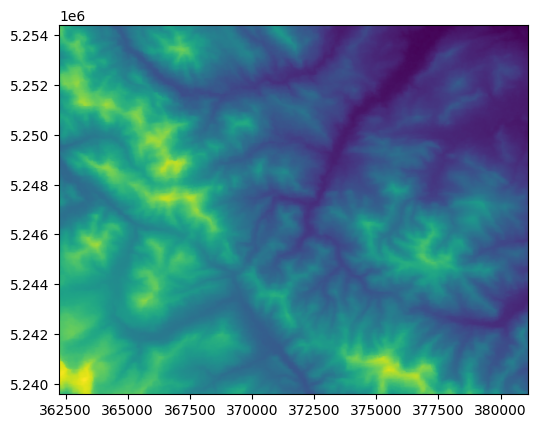

<Axes: >

In [2]:
# Open raster image 
rasterObj = rasterio.open('../rst/ASTGTM_NAD83_12N.tif')
show(rasterObj)

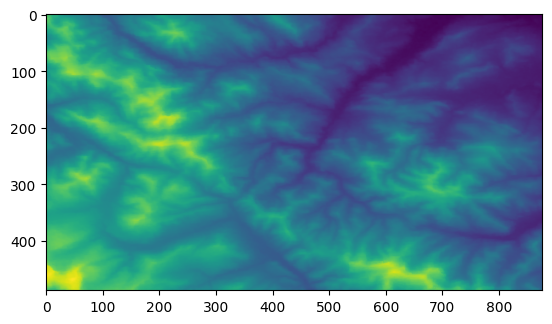

In [3]:
#extract array from raster
elevArray = rasterObj.read(1)
plt.imshow(elevArray)

In [4]:
#show array values
elevArray

array([[2319, 2319, 2296, ..., 1373, 1373, 1373],
       [2325, 2325, 2309, ..., 1371, 1373, 1373],
       [2334, 2334, 2315, ..., 1375, 1374, 1375],
       ...,
       [2307, 2306, 2307, ..., 1800, 1799, 1789],
       [2299, 2295, 2295, ..., 1800, 1799, 1789],
       [2282, 2281, 2295, ..., 1814, 1805, 1796]],
      shape=(488, 877), dtype=int16)

In [5]:
#create grid from raster attributes
nrows = rasterObj.height  # number of raster cells on each side, initially 150
ncols = rasterObj.width
dxy = (rasterObj.transform.a,-rasterObj.transform.e)  # side length of a raster model cell, or resolution [m], initially 50

# define a landlab raster
mg = RasterModelGrid(shape=(nrows, ncols), 
                     xy_spacing=dxy,
                     xy_of_lower_left=(rasterObj.bounds[0],rasterObj.bounds[1]))

# show number of rows, cols and resolution
print(nrows, ncols, dxy)

488 877 (21.514978563283933, 30.461871721312313)


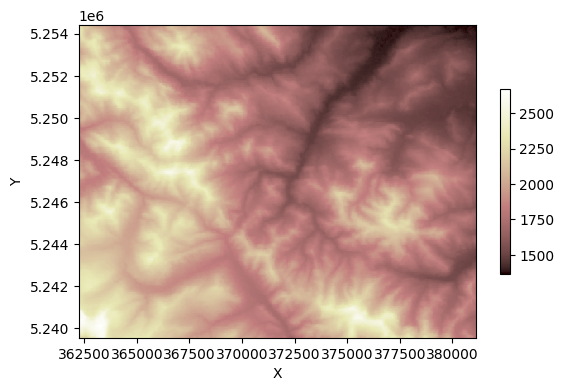

In [6]:
# create a dataset of zero values
zr = mg.add_zeros("topographic__elevation", at="node")

# apply cell elevation to defined arrray
zr += elevArray[::-1,:].ravel()

imshow_grid(mg, "topographic__elevation", shrink=0.5)

In [7]:
#clear empty values
mg.set_nodata_nodes_to_closed(zr, -9999)

In [8]:
#flow direction
fa = FlowAccumulator(mg, flow_director='D4')
fa.run_one_step()

#fill sinks
df = DepressionFinderAndRouter(mg)
df.map_depressions()

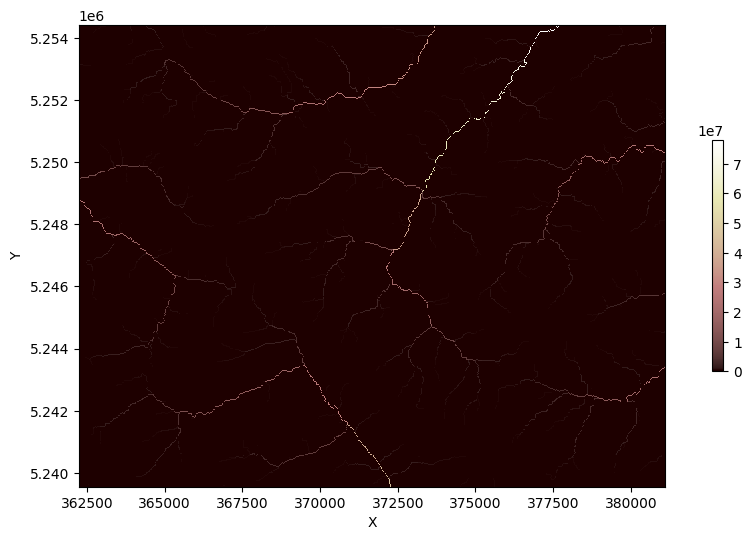

In [9]:
#plot corrected drainage area
fig = plt.figure(figsize=(12,6))
imshow_grid(mg, 'drainage_area', shrink=0.5)

In [10]:
#profile the channel networks
profiler = ChannelProfiler(
    mg,
    number_of_watersheds=5,
    minimum_channel_threshold=1000000,
    main_channel_only=False)

#run profiler
profiler.run_one_step()

#extract profile dict
profDict = profiler.data_structure

In [11]:
#create a geopandas dataframe to store the channel network
multiLineList = []
multiLineIndex = []

for disPoint in profDict.keys():
    segDict = profDict[disPoint]   
    for segItem in segDict.keys():   
        coordList = []      
        nodeArray = segDict[segItem]['ids']
        for node in nodeArray:
            coordList.append([mg.x_of_node[node],mg.y_of_node[node]])
        multiLine = LineString(coordList)
        multiLineList.append(multiLine)
        multiLineIndex.append(segItem)
colDict = {'nodeStart':[a[0] for a in multiLineIndex],
          'nodeEnd':[a[1] for a in multiLineIndex]}
gdf = gpd.GeoDataFrame(colDict,index=range(len(multiLineIndex)), crs='epsg:'+str(rasterObj.crs.to_epsg()), geometry=multiLineList)

In [12]:
#show resulting geodataframe
gdf.head()

,nodeStart,nodeEnd,geometry
0,264854,233330,"LINESTRING (362247.471 5248767.789, 362268.986..."
1,233330,206983,"LINESTRING (363280.19 5247671.162, 363301.705 ..."
2,233330,212344,"LINESTRING (363280.19 5247671.162, 363301.705 ..."
3,212344,195715,"LINESTRING (364614.119 5246940.077, 364635.634..."
4,212344,213229,"LINESTRING (364614.119 5246940.077, 364635.634..."


In [13]:
#export geodataframe to shapefile
gdf.to_file('../output/waterNetwork.shp')

<Axes: >

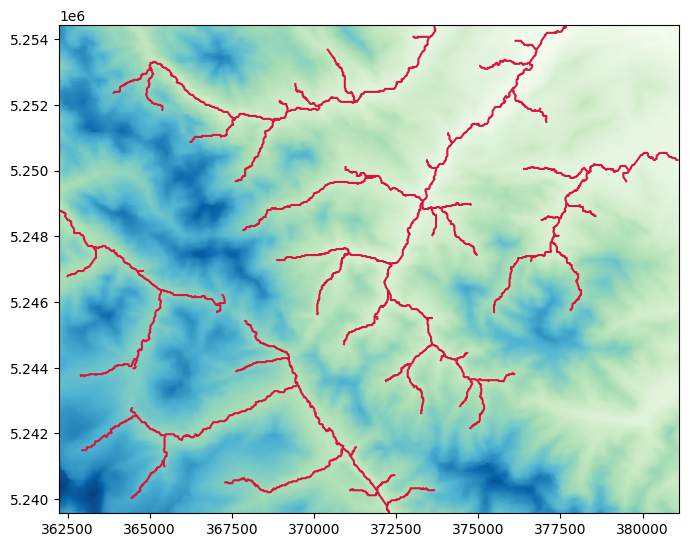

In [14]:
#plot raster with stream networks
fig,ax = plt.subplots(figsize=(8,8))
show(rasterObj, ax=ax, cmap='GnBu')
gdf.plot(ax=ax, color='crimson')